# README

Notebook que treina e testa o modelo já reduzido

In [1]:
import torch
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))
    print("Versão CUDA do PyTorch:", torch.version.cuda)

CUDA disponível: False


In [2]:
dimension = [8,16]

# Arquitetura 
As entradas foram reduzidas para 8x16. 
É uma rede simples, com uma camada fully connected. 


## Carregar o dataset

In [3]:
from torchvision import datasets, transforms
import os

transform = transforms.Compose([
    transforms.Grayscale(),     
    transforms.Resize((75, 100)),
    transforms.ToTensor()
])

!ls CNN_letter_Dataset/test

test_data  = datasets.ImageFolder(root="CNN_letter_Dataset/test", transform=transform)
train_data  = datasets.ImageFolder(root="CNN_letter_Dataset/train", transform=transform)

# --- DataLoaders ---
train_loader = torch.utils.data.DataLoader(train_data, batch_size=10, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=10, shuffle=False)

# --- Informações básicas ---
print(f"Total de imagens de treino: {len(train_data)}")
print(f"Total de imagens de teste:  {len(test_data)}")

'ls' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


Total de imagens de treino: 28400
Total de imagens de teste:  7100


### Normalizar o dataset

In [4]:
import torch.nn.functional as F

interpolate = True
important = False
def interpolate_image(img_tensor, new_dim=dimension):
    """
    Recebe uma imagem [C,H,W] ou [H,W] e retorna vetor [num_top_pixels]
    contendo apenas os pixels mais importantes no novo espaço.
    """
    # Remove canal se necessário
    img = img_tensor.squeeze()  # [H, W]
    img_resized = F.interpolate(
        img.unsqueeze(0).unsqueeze(0),  # adiciona batch e canal
        size=(new_dim[0], new_dim[1]),
        mode='bilinear',
        align_corners=False
    ).squeeze()  # remove batch e canal

    return img_resized.flatten()  

In [5]:
from torch.utils.data import TensorDataset, DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reduz conjunto de treino
#X_train_reduced = torch.stack([reduce_image(img, top_pixel_coordinates_int) for img, _ in train_data])
X_train_reduced = torch.stack([interpolate_image(img) for img, _ in train_data])
y_train = torch.tensor([label for _, label in train_data])


# Reduz conjunto de teste
X_test_reduced = torch.stack([interpolate_image(img) for img, _ in test_data])
y_test = torch.tensor([label for _, label in test_data])

print(f"Novo shape de treino: {X_train_reduced.shape}")
print(f"Novo shape de teste:  {X_test_reduced.shape}")

# DataLoaders
batch_size = 10
train_loader_reduced = DataLoader(TensorDataset(X_train_reduced, y_train), batch_size=batch_size, shuffle=True)
test_loader_reduced = DataLoader(TensorDataset(X_test_reduced, y_test), batch_size=batch_size)


Novo shape de treino: torch.Size([28400, 128])
Novo shape de teste:  torch.Size([7100, 128])


In [6]:
for x, y in test_loader:
    print(x.shape)
    break


torch.Size([10, 1, 75, 100])


## Modelo

In [7]:
import torch.nn as nn

num_pixels = dimension[0] * dimension[1]  
n_classes = len(train_data.classes)    

model_small = nn.Sequential(
    nn.Linear(num_pixels, n_classes)
)
print(num_pixels)


128


## Treinamento

In [8]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
model_small.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_small.parameters(), lr=0.1)

epochs = 5
losses_interpolate = []

for epoch in range(epochs):
    print(f'Epoch: {epoch}')
    model_small.train()
    total_loss = 0
    
    for X_batch, y_batch in tqdm(train_loader_reduced):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model_small(X_batch)
        loss = criterion(output, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    

    losses_interpolate.append(total_loss / len(train_loader_reduced))
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader_reduced):.4f}")



Epoch: 0


100%|██████████| 2840/2840 [00:02<00:00, 1269.38it/s]


Epoch 1, Loss: 1.7612
Epoch: 1


100%|██████████| 2840/2840 [00:01<00:00, 1434.35it/s]


Epoch 2, Loss: 0.8894
Epoch: 2


...

Epoch 3, Loss: 0.6959
Epoch: 3


100%|██████████| 2840/2840 [00:06<00:00, 420.22it/s]


Epoch 4, Loss: 0.5996
Epoch: 4


100%|██████████| 2840/2840 [00:06<00:00, 448.43it/s]

Epoch 5, Loss: 0.5405


In [9]:
print(losses_interpolate)

[1.761214150845165, 0.8894416513472376, 0.6958541497902971, 0.599572792630905, 0.5404634328795151]


In [10]:
import numpy as np
import os

# criar pastas caso não existam
os.makedirs("values/weights", exist_ok=True)
os.makedirs("values/bias", exist_ok=True)

weights = model_small[0].weight.data.cpu().numpy()
bias = model_small[0].bias.data.cpu().numpy()

np.save("values/weights/weights_original.npy", weights)
np.save("values/bias/bias_original.npy", bias)
    
np.savetxt("values/weights/weights_original.txt", weights)
np.savetxt("values/bias/bias_original.txt", bias)

## Teste

In [11]:
from torch.utils.data import TensorDataset, DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Lista de imagens reduzidas usando as coordenadas corretas
X_test_reduced = torch.stack([interpolate_image(img) for img, _ in test_data])
y_test = torch.tensor([label for _, label in test_data])

print(f"Shape do dataset reduzido: {X_test_reduced.shape}")  # deve ser (N_test, num_top_pixels)

# DataLoader para o modelo reduzido
test_loader_reduced = DataLoader(
    TensorDataset(X_test_reduced, y_test),
    batch_size=10,  # ou outro batch_size que quiser
    shuffle=False
)

Shape do dataset reduzido: torch.Size([7100, 128])


In [12]:
def calc_loss_reduced(model, criterion, loader):
    """
    Calcula a loss média de um modelo MLP que recebe entradas já achatadas.
    loader: DataLoader do dataset reduzido (ex: test_loader_reduced)
    """
    batch_losses = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)
            loss = criterion(output, label_batch).item()
            batch_losses.append(loss)

    mean_loss = sum(batch_losses) / len(batch_losses)
    return batch_losses, mean_loss


In [13]:
batch_losses_interpolate, mean_loss_interpolate = calc_loss_reduced(model_small, criterion, test_loader_reduced)
print(f"Loss média: {mean_loss_interpolate:.4f}")
print(f"Loss por batch (primeiros 5): {batch_losses_interpolate[:10]}")


Loss média: 0.5272
Loss por batch (primeiros 5): [0.5696998834609985, 0.9094451069831848, 1.0011675357818604, 0.28340715169906616, 1.8332312107086182, 0.6486265659332275, 0.6636497974395752, 0.9501460790634155, 0.47528648376464844, 0.6962186098098755]


In [14]:
def calc_accuracy_reduced(model, loader, n_classes=None):
    """
    Calcula acurácia geral e por classe de um modelo MLP.
    loader: DataLoader do dataset reduzido.
    n_classes: número de classes (se None, inferido do loader).
    """
    if n_classes is None:
        n_classes = len(loader.dataset.tensors[1].unique())
    
    correct_total = 0
    total_total = 0
    correct_per_class = {i: 0 for i in range(n_classes)}
    total_per_class = {i: 0 for i in range(n_classes)}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        for img_batch, label_batch in loader:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)

            output = model(img_batch)
            preds = output.argmax(dim=1)

            correct_total += (preds == label_batch).sum().item()
            total_total += len(label_batch)

            for i in range(len(label_batch)):
                label = label_batch[i].item()
                total_per_class[label] += 1
                if preds[i] == label_batch[i]:
                    correct_per_class[label] += 1

    class_acc = {cls: correct_per_class[cls]/total_per_class[cls] 
                 if total_per_class[cls] > 0 else 0
                 for cls in range(n_classes)}

    overall_acc = correct_total / total_total
    return overall_acc, class_acc


In [15]:
overall_acc_interpolate, class_acc_interpolate = calc_accuracy_reduced(model_small, test_loader_reduced)
print(f"Acurácia geral: {overall_acc_interpolate*100:.2f}%")
for cls, acc in class_acc_interpolate.items():
    print(f"Classe {cls}: {acc*100:.2f}%")

Acurácia geral: 88.58%
Classe 0: 85.44%
Classe 1: 88.83%
Classe 2: 93.20%
Classe 3: 92.23%
Classe 4: 94.17%
Classe 5: 96.60%
Classe 6: 84.47%
Classe 7: 86.41%
Classe 8: 73.30%
Classe 9: 87.38%
Classe 10: 87.13%
Classe 11: 73.79%
Classe 12: 94.61%
Classe 13: 97.03%
Classe 14: 95.05%
Classe 15: 94.61%
Classe 16: 93.63%
Classe 17: 96.57%
Classe 18: 60.40%
Classe 19: 98.06%
Classe 20: 97.52%
Classe 21: 94.06%
Classe 22: 96.08%
Classe 23: 89.71%
Classe 24: 87.62%
Classe 25: 64.36%
Classe 26: 92.65%
Classe 27: 88.24%
Classe 28: 89.22%
Classe 29: 89.11%
Classe 30: 80.10%
Classe 31: 95.54%
Classe 32: 89.11%
Classe 33: 77.23%
Classe 34: 98.77%


In [16]:
overall_acc_interpolate, class_acc_interpolate = calc_accuracy_reduced(model_small, test_loader_reduced)

# Nome do arquivo
output_file = "values/accuracy/original.txt"

with open(output_file, "w") as f:
    f.write(f"Acurácia geral: {overall_acc_interpolate*100:.2f}%\n\n")
    f.write("Acurácia por classe:\n")
    for cls, acc in class_acc_interpolate.items():
        f.write(f"Classe {cls}: {acc*100:.2f}%\n")

print("Acurácia salva em:", output_file)


Acurácia salva em: values/accuracy/original.txt


# Normalização e Quantização dos pesos

Normalização

In [17]:
def normalize_weights(model):
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' in name:  # normaliza apenas pesos, não bias
                w = param.data
                w_min = w.min()
                w_max = w.max()
                
                # evita divisão por zero caso w_max == w_min
                if w_max != w_min:
                    param.data = (w - w_min) / (w_max - w_min)
                else:
                    param.data = torch.zeros_like(w)


In [18]:
import copy
model_norm = copy.deepcopy(model_small)
normalize_weights(model_norm)

In [19]:
overall_acc_norm, class_acc_norm = calc_accuracy_reduced(model_norm, test_loader_reduced)

print(f"Acurácia geral (pesos normalizados): {overall_acc_norm*100:.2f}%")

for cls, acc in class_acc_norm.items():
    print(f"Classe {cls}: {acc*100:.2f}%")

import os

os.makedirs("values/accuracy", exist_ok=True)

with open("values/accuracy/accuracy_norm_01.txt", "w") as f:
    f.write(f"Acurácia geral: {overall_acc_norm*100:.2f}%\n\n")
    
    for cls, acc in class_acc_norm.items():
        f.write(f"Classe {cls}: {acc*100:.2f}%\n")


Acurácia geral (pesos normalizados): 35.38%
Classe 0: 0.00%
Classe 1: 48.06%
Classe 2: 66.50%
Classe 3: 45.63%
Classe 4: 35.92%
Classe 5: 58.25%
Classe 6: 12.62%
Classe 7: 10.68%
Classe 8: 71.84%
Classe 9: 1.46%
Classe 10: 77.23%
Classe 11: 96.12%
Classe 12: 2.94%
Classe 13: 0.00%
Classe 14: 30.69%
Classe 15: 7.84%
Classe 16: 1.47%
Classe 17: 0.98%
Classe 18: 1.98%
Classe 19: 28.64%
Classe 20: 66.34%
Classe 21: 31.19%
Classe 22: 100.00%
Classe 23: 57.35%
Classe 24: 0.00%
Classe 25: 86.63%
Classe 26: 32.84%
Classe 27: 0.00%
Classe 28: 0.98%
Classe 29: 10.89%
Classe 30: 36.89%
Classe 31: 87.62%
Classe 32: 89.60%
Classe 33: 0.00%
Classe 34: 40.12%


In [20]:
import numpy as np
import os

os.makedirs("values/weights", exist_ok=True)

weights_norm = model_norm[0].weight.data.cpu().numpy()

np.save("values/weights/weights_norm_01.npy", weights_norm)

np.savetxt("values/weights/weights_norm_01.txt", weights_norm)


Quantização bits

In [21]:
def quantize_weights(model, num_bits):
    """
    Quantiza todos os pesos do modelo para 'num_bits' bits (uniforme).
    Não afeta os bias.
    """
    with torch.no_grad():
        for name, param in model.named_parameters():
            if "weight" in name:
                w = param.data
                w_min = w.min()
                w_max = w.max()
                
                if w_max != w_min:
                    levels = 2**num_bits - 1   # número de níveis
                    delta = (w_max - w_min) / levels
                    
                    # quantização uniforme
                    wq = torch.round((w - w_min) / delta) * delta + w_min
                    
                    param.data = wq
                else:
                    # caso todos pesos sejam iguais
                    param.data = torch.zeros_like(w)

model_quant = copy.deepcopy(model_small)
num_bits = 8
quantize_weights(model_quant, num_bits=num_bits)

acc, acc_cls = calc_accuracy_reduced(model_quant, test_loader_reduced)
print(f"Acurácia geral (pesos quantizados {num_bits} bits): {acc*100:.2f}%")

for cls, acc in acc_cls.items():
    print(f"Classe {cls}: {acc*100:.2f}%")


Acurácia geral (pesos quantizados 8 bits): 88.51%
Classe 0: 85.44%
Classe 1: 88.83%
Classe 2: 93.20%
Classe 3: 92.23%
Classe 4: 94.17%
Classe 5: 96.60%
Classe 6: 84.47%
Classe 7: 86.89%
Classe 8: 73.30%
Classe 9: 87.38%
Classe 10: 87.13%
Classe 11: 73.30%
Classe 12: 94.61%
Classe 13: 96.04%
Classe 14: 95.05%
Classe 15: 94.61%
Classe 16: 94.12%
Classe 17: 96.08%
Classe 18: 60.89%
Classe 19: 97.57%
Classe 20: 97.52%
Classe 21: 94.55%
Classe 22: 96.08%
Classe 23: 89.71%
Classe 24: 87.13%
Classe 25: 64.36%
Classe 26: 92.16%
Classe 27: 88.24%
Classe 28: 89.71%
Classe 29: 89.60%
Classe 30: 79.13%
Classe 31: 95.54%
Classe 32: 88.12%
Classe 33: 77.23%
Classe 34: 98.77%


In [22]:
import os
os.makedirs("values/weights", exist_ok=True)
os.makedirs("values/bias", exist_ok=True)

weights_q = model_quant[0].weight.data.cpu().numpy()

np.save(f"values/weights/weights_quant{num_bits}.npy", weights_q)

np.savetxt(f"values/weights/weights_quant{num_bits}.txt", weights_q)

with open(f"values/accuracy/accuracy_quant{num_bits}.txt", "w") as f:
    f.write(f"Acurácia geral: {acc*100:.2f}%\n\n")
    for cls, acc in acc_cls.items():
        f.write(f"Classe {cls}: {acc*100:.2f}%\n")

# Quantização dataset


In [23]:
import torch

def quantize_tensor(x, num_bits):
    # Níveis de quantização
    levels = 2**num_bits - 1
    max_int = (levels - 1) // 2  # ex: 4 bits -> max_int = 7

    # Normaliza entrada para [-1, 1]
    x_norm = x / x.abs().max()

    # Quantização uniforme simétrica
    x_q = torch.round(x_norm * max_int)

    # Reconstrução (dequantização)
    x_deq = x_q / max_int

    return x_deq

def test_with_quantized_input(model, dataloader, num_bits):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            # quantiza somente a entrada
            Xq = quantize_tensor(X, num_bits)

            # passa pelo modelo
            outputs = model(Xq)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


num_bits = 2  # tenta 4 bits primeiro

acc_input_quant = test_with_quantized_input(model_small, test_loader_reduced, num_bits)

print(f"Acurácia com entrada quantizada para {num_bits} bits: {acc_input_quant*100:.2f}%")



Acurácia com entrada quantizada para 2 bits: 84.58%


In [24]:
import copy
import torch

def quantize_model_weights(model, num_bits):
    model_q = copy.deepcopy(model)

    levels = 2**num_bits - 1
    max_int = (levels - 1) // 2

    with torch.no_grad():
        for name, param in model_q.named_parameters():
            if "weight" in name or "bias" in name:
                w = param.data
                w_norm = w / w.abs().max()  # normaliza para [-1, 1]
                w_q = torch.round(w_norm * max_int) / max_int
                param.data = w_q

    return model_q

def quantize_input(x, num_bits):
    levels = 2**num_bits - 1
    max_int = (levels - 1) // 2
    x_norm = x / x.abs().max()
    x_q = torch.round(x_norm * max_int) / max_int
    return x_q



In [25]:
def test_model(model, dataloader, bits_weight, bits_input):
    
    # quantiza pesos primeiro
    model_q = quantize_model_weights(model, bits_weight)
    model_q.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            # quantiza entrada
            Xq = quantize_input(X, bits_input)

            # inferência
            out = model_q(Xq)
            pred = out.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total


In [26]:
bits_weights = [2, 4, 8, 16]
bits_inputs  = [2, 4, 8, 16]

results = {}  # (peso_bits, entrada_bits) -> acurácia

for bw in bits_weights:
    for bi in bits_inputs:
        acc = test_model(model_small, test_loader_reduced, bw, bi)
        results[(bw, bi)] = acc
        print(f"Pesos {bw} bits, Entrada {bi} bits -> {acc*100:.2f}%")


Pesos 2 bits, Entrada 2 bits -> 17.07%
Pesos 2 bits, Entrada 4 bits -> 9.03%
Pesos 2 bits, Entrada 8 bits -> 9.06%
Pesos 2 bits, Entrada 16 bits -> 9.06%
Pesos 4 bits, Entrada 2 bits -> 82.04%
Pesos 4 bits, Entrada 4 bits -> 79.92%
Pesos 4 bits, Entrada 8 bits -> 80.42%
Pesos 4 bits, Entrada 16 bits -> 80.46%
Pesos 8 bits, Entrada 2 bits -> 84.28%
Pesos 8 bits, Entrada 4 bits -> 87.15%
Pesos 8 bits, Entrada 8 bits -> 87.93%
Pesos 8 bits, Entrada 16 bits -> 87.85%
Pesos 16 bits, Entrada 2 bits -> 84.39%
Pesos 16 bits, Entrada 4 bits -> 87.10%
Pesos 16 bits, Entrada 8 bits -> 87.89%
Pesos 16 bits, Entrada 16 bits -> 87.85%


In [27]:
all_inputs = []

for X, y in test_loader_reduced:
    Xq = quantize_input(X, num_bits=16)
    all_inputs.append(Xq.cpu())

all_inputs = torch.cat(all_inputs, dim=0).numpy()
np.savetxt("values/inputs/inputs_quantized_16.txt", all_inputs.reshape(-1))


In [28]:
X, y = next(iter(test_loader_reduced))     # pega um batch
Xq = quantize_input(X, num_bits=4)         # quantiza (muda o valor se quiser)

np.savetxt("inputs_quantized_4bits_batch.txt", Xq.cpu().numpy().reshape(-1))


[[0.8804586  0.8804586  0.8760119  0.8807712  0.87187773 0.86399174
  0.8182734  0.6436686  0.36800414 0.24905333 0.28570437 0.52728856
  0.79315615 0.83105785 0.827827   0.8190377 ]
 [0.89185333 0.89185345 0.89046377 0.87062716 0.3162411  0.29293033
  0.26374847 0.2788605  0.313983   0.41070002 0.3327775  0.28827515
  0.29282612 0.2523884  0.2059406  0.85315263]
 [0.92075735 0.92075735 0.82188636 0.31471252 0.27646342 0.26444328
  0.8437728  0.8973076  0.91221124 0.89352095 0.8976898  0.8928609
  0.75004345 0.30255342 0.29129755 0.26882058]
 [0.9451798  0.73149216 0.34441552 0.31155115 0.31422615 0.93923914
  0.91214174 0.9293729  0.9265938  0.92492616 0.9124197  0.85478544
  0.3057495  0.2989057  0.2964739  0.6253605 ]
 [0.55692196 0.33361125 0.31818655 0.3272538  0.96779567 0.9455967
  0.94698626 0.93850964 0.9354525  0.9355914  0.81841236 0.34055933
  0.31318396 0.30508947 0.8593712  0.9326732 ]
 [0.34962657 0.33159631 0.30324823 0.9932951  0.9519889  0.9518846
  0.9518846  0.95188

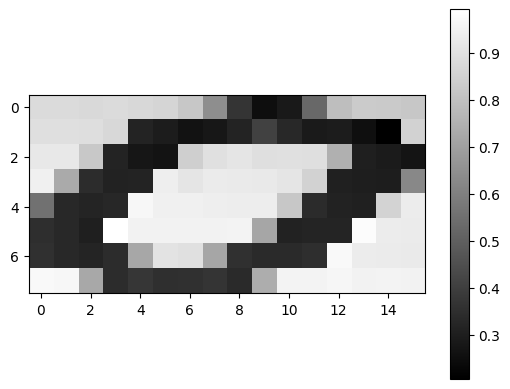

In [39]:
Xq = quantize_input(X, 32)

img_q = Xq[9].cpu().numpy()   # pega a 1ª imagem do batch
img_q = img_q.squeeze()        # remove canal
img_q = img_q.reshape(8, 16)   # força formato correto

print(img_q)
print(img_q.shape)  # deve ser (8, 16)

import matplotlib.pyplot as plt

plt.imshow(img_q, cmap="gray")
plt.colorbar()
plt.show()
